In [37]:
import pandas as pd
import numpy as np

expr = pd.read_csv(
    "../data/processed/expression_matrix.csv"
)

expr.iloc[:,1:] = np.log2(expr.iloc[:,1:] + 1)

variance = expr.iloc[:,1:].var(axis=1)

expr = expr.loc[variance > 0.1]

In [38]:
labels = [
    "CVD",
    "Control",
    ...
]

In [39]:
from scipy.stats import ttest_ind

results = []

for i in range(len(expr)):
    
    gene = expr.iloc[i,0]
    
    values = expr.iloc[i,1:]
    
    cvd = values[:20].astype(float)
    control = values[20:].astype(float)

    stat, p = ttest_ind(cvd, control)
    
    fold_change = cvd.mean() - control.mean()
    
    results.append([
        gene,
        fold_change,
        p
    ])

deg = pd.DataFrame(
    results,
    columns=["gene", "logFC", "pvalue"]
)

In [45]:
print(expr.shape)

print(expr.head())

print(expr.columns[:10])
print(expr.iloc[:5, :5])

(20982, 223)
        gene  GSM308566  GSM308567  GSM308568  GSM308569  GSM308570  \
0  1007_s_at   6.881175   7.336373   6.534653   6.913009   7.417262   
1    1053_at   5.626439   6.158458   5.888743   6.736199   6.392489   
2     117_at   7.704457   8.368856   7.409730   9.542452   8.417853   
3     121_at   9.210111   8.504382   9.085791   8.766032   9.576673   
4  1255_g_at   5.683416   2.821710   3.253989   5.001352   3.285402   

   GSM308571  GSM308572  GSM308573  GSM308574  ...  GSM308778  GSM308779  \
0   6.845365   6.739713   7.012569   6.679902  ...   7.677579   6.764474   
1   6.598127   6.157448   4.413459   6.001352  ...   5.385431   4.456806   
2   7.926593   7.618899   8.749266   8.278821  ...   8.470944   8.792367   
3   9.085207   8.396305   8.806872   8.821838  ...   9.743067   9.314493   
4   4.745775   2.173127   4.858976   2.189034  ...   4.108524   5.246028   

   GSM308780  GSM308781  GSM308782  GSM308783  GSM308784  GSM308785  \
0   7.086614   6.819413   7.0441

In [43]:
from statsmodels.stats.multitest import multipletests

deg["adj_pvalue"] = multipletests(
    deg["pvalue"],
    method="fdr_bh"
)[1]

sig = deg[
    (deg["adj_pvalue"] < 0.25)
]

sig.to_csv(
    "../outputs/tables/significant_genes.csv",
    index=False
)

print(sig.shape)

(0, 4)


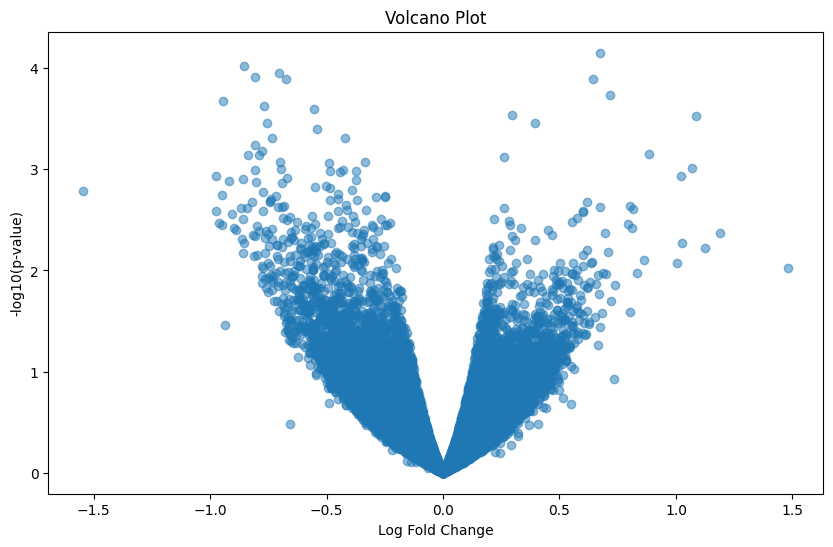

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    deg["logFC"],
    -np.log10(deg["pvalue"]),
    alpha=0.5
)

plt.xlabel("Log Fold Change")
plt.ylabel("-log10(p-value)")
plt.title("Volcano Plot")

plt.savefig("../outputs/figures/volcano_plot.png")

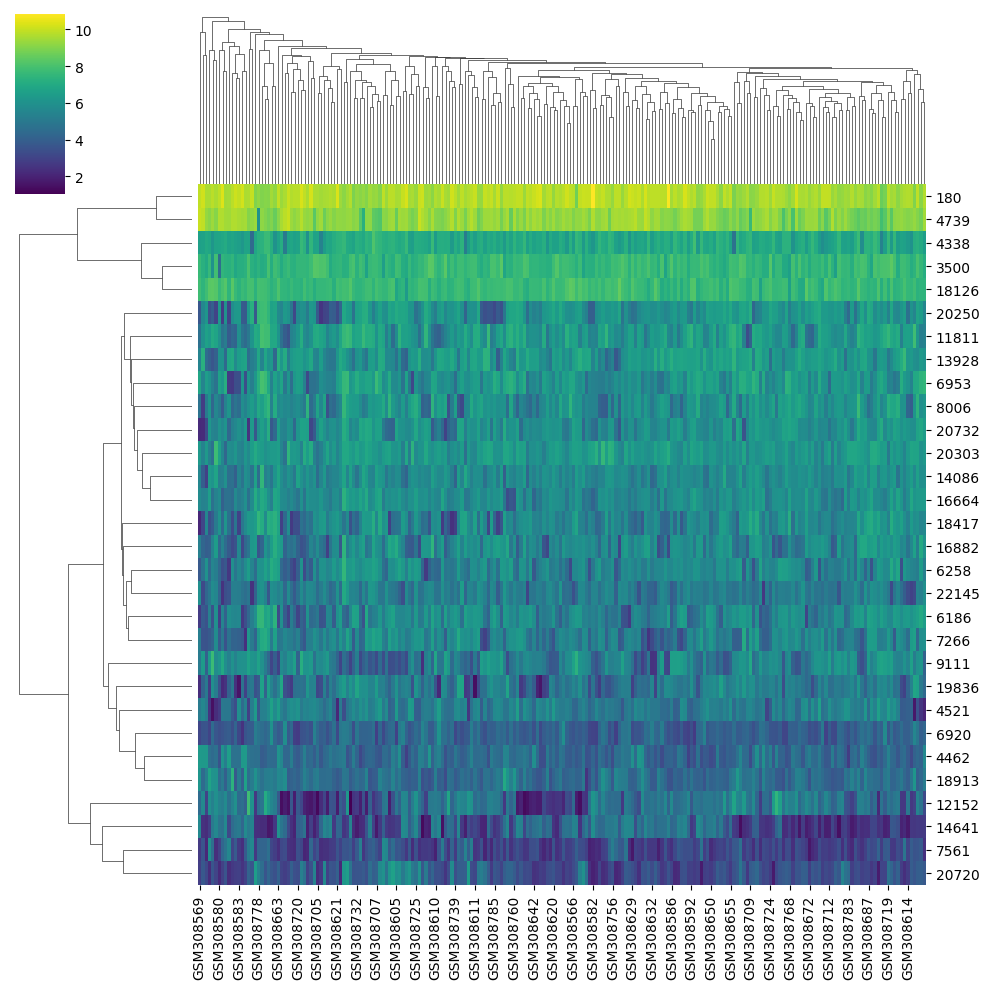

In [42]:
import seaborn as sns

top = deg.sort_values(by="pvalue").head(30)

heatmap_data = expr[
    expr["gene"].isin(top["gene"])
]

sns.clustermap(
    heatmap_data.iloc[:,1:],
    cmap="viridis"
)

plt.savefig("../outputs/figures/heatmap.png")